# Inspect Remote Saved Video

This notebook inspects the saved experiment on `mcluster11`, copies the needed files over SSH, and plays the saved `frame-recording.npy` locally.

In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from pathlib import Path
import ast
import shlex
import subprocess
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.opencv_video_utils import videoPlayer

In [3]:
REMOTE_HOST = 'ethantu@mcluster11.wisdom.weizmann.ac.il'
REMOTE_DIR = '/net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-09x00y_0010--31-03-20-42-51'

CACHE_DIR = repo_root / 'artifacts' / 'remote_video_cache' / Path(REMOTE_DIR).name
CACHE_DIR.mkdir(parents=True, exist_ok=True)

FRAME_RECORDING_PATH = CACHE_DIR / 'frame-recording.npy'
METADATA_PATH = CACHE_DIR / 'metadata.npz'
OVERHEAD_IMAGE_PATH = CACHE_DIR / 'box_overhead_image.png'

CACHE_DIR

PosixPath('/Users/eitanturok/good-vibrations/artifacts/remote_video_cache/cube-09x00y_0010--31-03-20-42-51')

In [4]:
def run_ssh(command: str, capture_output: bool = True):
    return subprocess.run(
        ['ssh', REMOTE_HOST, command],
        check=True,
        text=True,
        capture_output=capture_output,
    )


def stream_remote_file(remote_path: str, local_path: Path, overwrite: bool = False) -> Path:
    if local_path.exists() and not overwrite:
        print(f'Using cached file: {local_path}')
        return local_path

    local_path.parent.mkdir(parents=True, exist_ok=True)
    remote_command = f"cat {shlex.quote(remote_path)}"
    print(f'Streaming {remote_path} -> {local_path}')
    with local_path.open('wb') as f:
        subprocess.run(['ssh', REMOTE_HOST, remote_command], check=True, stdout=f)
    return local_path


def fetch_remote_bytes(remote_path: str, count: int, skip: int = 0) -> bytes:
    remote_command = (
        'sh -lc ' + shlex.quote(
            f"dd if={shlex.quote(remote_path)} bs=1 skip={skip} count={count} 2>/dev/null"
        )
    )
    result = subprocess.run(['ssh', REMOTE_HOST, remote_command], check=True, capture_output=True)
    return result.stdout


def inspect_remote_recording(remote_npy_path: str) -> dict:
    header_bytes = fetch_remote_bytes(remote_npy_path, count=256)
    if header_bytes[:6] != b'\x93NUMPY':
        raise ValueError('Remote file is not a .npy file')

    major, minor = header_bytes[6], header_bytes[7]
    if major == 1:
        header_len = int.from_bytes(header_bytes[8:10], 'little')
        start = 10
    else:
        header_len = int.from_bytes(header_bytes[8:12], 'little')
        start = 12

    header = header_bytes[start:start + header_len].decode('latin1')
    payload = ast.literal_eval(header)
    payload['version'] = (major, minor)
    payload['data_offset'] = start + header_len
    return payload


def stretch_contrast(image, minmax=None):
    if minmax is None:
        min_val = np.min(image)
        max_val = np.max(image)
    else:
        min_val, max_val = minmax
    return cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)


def preview_video(frame_recording, resize_factor=2):
    class videoPlayerv2(videoPlayer):
        def additional_loop_control(self, key):
            if key == 42:
                self.data_counter = (self.data_counter + 100) % self.N_frames
            if key == 47:
                self.data_counter = (self.data_counter - 100) % self.N_frames

    def get_frameshow(data_counter):
        frame = frame_recording[data_counter].copy()
        frame_show = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        frame_show = stretch_contrast(frame_show)
        return frame_show

    player = videoPlayerv2(get_frameshow, frame_recording.shape[0], resize_factor=resize_factor)
    player.play_video(move_window=0, show_frame_number=True)


def export_preview_clip(frame_recording, output_path: Path, start=0, stop=300, step=10, fps=25):
    indices = list(range(start, min(stop, frame_recording.shape[0]), step))
    if not indices:
        raise ValueError('No frames selected for preview clip')

    first = stretch_contrast(frame_recording[indices[0]])
    first = cv2.cvtColor(first, cv2.COLOR_GRAY2BGR)
    h, w = first.shape[:2]
    writer = cv2.VideoWriter(str(output_path), cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    try:
        for idx in indices:
            frame = stretch_contrast(frame_recording[idx])
            frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
            cv2.putText(frame, f'frame {idx}', (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 255), 2, cv2.LINE_AA)
            writer.write(frame)
    finally:
        writer.release()

    return output_path

In [5]:
print(run_ssh(f'ls -lah {shlex.quote(REMOTE_DIR)}').stdout)
recording_info = inspect_remote_recording(f'{REMOTE_DIR}/frame-recording.npy')
recording_info

total 2.7G
drwxrwx---   2 ethantu marksheg  256 Apr 13 21:14 .
drwxrwx--- 618 ethantu marksheg  31K Apr 12 12:57 ..
-rw-r--r--   1 ethantu marksheg 6.9M Apr 12 11:23 RECOVERY.npz
-rwxrw----   1 ethantu marksheg 4.1M Mar 31 20:42 box_overhead_image.png
-rw-r--r--   1 ethantu marksheg  24K Apr 12 11:23 err.log
-rwxrw----   1 ethantu marksheg  683 Mar 31 20:42 experiment_config.json
-rwxrw----   1 ethantu marksheg 2.9G Mar 31 20:42 frame-recording.npy
-rwxrw----   1 ethantu marksheg 2.6K Mar 31 20:42 metadata.npz
-rw-r--r--   1 ethantu marksheg  15K Apr 12 11:23 out.log
-rwxrw----   1 ethantu marksheg   56 Apr 12 11:26 status.json



{'descr': '|u1',
 'fortran_order': False,
 'shape': (9000, 300, 1152),
 'version': (1, 0),
 'data_offset': 128}

Using cached file: /Users/eitanturok/good-vibrations/artifacts/remote_video_cache/cube-09x00y_0010--31-03-20-42-51/metadata.npz
Using cached file: /Users/eitanturok/good-vibrations/artifacts/remote_video_cache/cube-09x00y_0010--31-03-20-42-51/box_overhead_image.png
experiment_name: cube-09x00y_0010
camera_FPS: 2500
global_ROI: (352, 0, 1152, 300)
remote shape: (9000, 300, 1152)


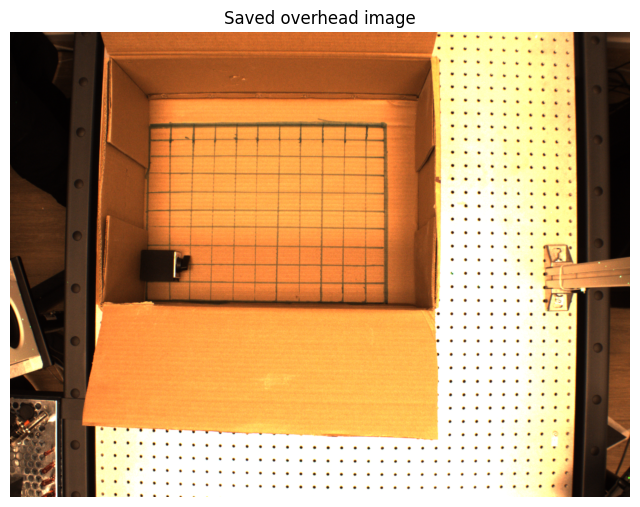

In [7]:
stream_remote_file(f'{REMOTE_DIR}/metadata.npz', METADATA_PATH)
stream_remote_file(f'{REMOTE_DIR}/box_overhead_image.png', OVERHEAD_IMAGE_PATH)

metadata = np.load(METADATA_PATH, allow_pickle=True)
run_opt = metadata['run_opt'].item()

print('experiment_name:', metadata['experiment_name'].item())
print('camera_FPS:', run_opt['cam_params']['camera_FPS'])
print('global_ROI:', run_opt['cam_params']['get_global_roi'])
print('remote shape:', recording_info['shape'])

overhead_image = plt.imread(OVERHEAD_IMAGE_PATH)
plt.figure(figsize=(8, 8))
plt.imshow(overhead_image)
plt.axis('off')
plt.title('Saved overhead image')
plt.show()

## Copy The Full Recording

`frame-recording.npy` is about 2.9 GB, so this cell may take a while the first time. It streams the file over SSH into `artifacts/remote_video_cache/...` and then loads it as a memory map.

In [8]:
stream_remote_file(f'{REMOTE_DIR}/frame-recording.npy', FRAME_RECORDING_PATH)
frame_recording = np.load(FRAME_RECORDING_PATH, mmap_mode='r')
frame_recording.shape, frame_recording.dtype

Streaming /net/mraid20/ifs/wisdom/groups/mark_sheinin_lab/DATA/experiment-15/cube-09x00y_0010--31-03-20-42-51/frame-recording.npy -> /Users/eitanturok/good-vibrations/artifacts/remote_video_cache/cube-09x00y_0010--31-03-20-42-51/frame-recording.npy


** WARNING: connection is not using a post-quantum key exchange algorithm.
** This session may be vulnerable to "store now, decrypt later" attacks.
** The server may need to be upgraded. See https://openssh.com/pq.html


((9000, 300, 1152), dtype('uint8'))

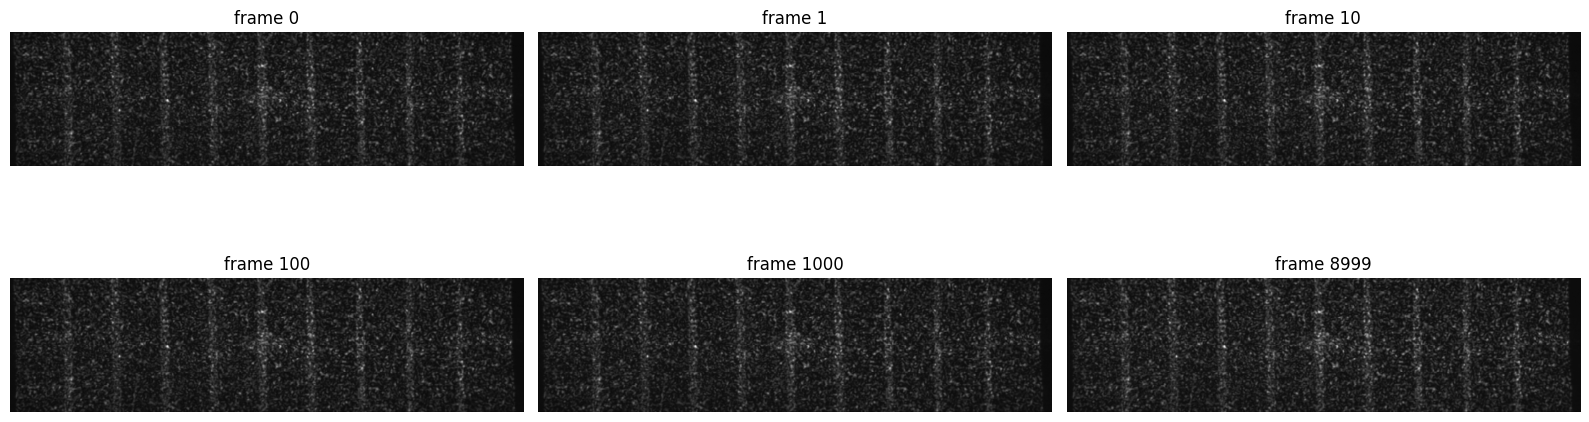

In [9]:
sample_indices = [0, 1, 10, 100, 1000, frame_recording.shape[0] - 1]
fig, axes = plt.subplots(2, 3, figsize=(16, 6))
for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(stretch_contrast(frame_recording[idx]), cmap='gray')
    ax.set_title(f'frame {idx}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [11]:
preview_path = CACHE_DIR / 'preview_first_300_frames.mp4'
export_preview_clip(frame_recording, preview_path, start=0, stop=300, step=10, fps=25)
display(Video(str(preview_path), embed=True))

In [ ]:
# Popup OpenCV player. Controls: `+`/`-` move by 1 frame, `*`/`/` move by 100 frames, `Enter` exits.
preview_video(frame_recording)